# X3ms Multivariate TCN With Correlated Synthetic Series

This notebook is a learning-first experiment.

We will:
- create several correlated time series
- make one target series depend on the others
- visualize the relationships
- compare a univariate TCN against a multivariate TCN

The main question is:

**If the target is partly determined by other series, does a multivariate TCN predict it better than a univariate TCN?**

## 1. Setup

We keep this notebook intentionally small so it is easier to learn from.

- `LOOKBACK` is the number of past steps the model sees
- `HORIZON` is how many steps ahead we predict
- `TARGET_COL` is the one series we care about forecasting

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

RANDOM_SEED = 42
N_STEPS = 3200
LOOKBACK = 48
HORIZON = 1
BATCH_SIZE = 128
EPOCHS = 14
LEARNING_RATE = 1e-3
HIDDEN_CHANNELS = 32
DROPOUT = 0.10
TARGET_COL = "y_target"
USE_CPU_ONLY = True

np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

if USE_CPU_ONLY:
    device = torch.device("cpu")
else:
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

device

device(type='cpu')

## 2. Create Correlated Series

We build four observed driver series and one target.

Design idea:
- `x1_driver` reacts to a smooth latent factor plus a periodic signal
- `x2_driver` is correlated with `x1_driver`, but with lag and smoothing
- `x3_driver` has its own cycle and trend, and still shares some common information
- `x4_noise` is mostly nuisance noise
- `y_target` depends on lagged values of `x1_driver`, `x2_driver`, and `x3_driver`

So the target is not random. It is deliberately built from the other series.

In [2]:
t = np.arange(N_STEPS)

latent = np.zeros(N_STEPS)
for i in range(1, N_STEPS):
    latent[i] = 0.93 * latent[i - 1] + np.random.normal(scale=0.25)

daily = np.sin(2 * np.pi * t / 24)
weekly = np.cos(2 * np.pi * t / (24 * 7))
slow_wave = np.sin(2 * np.pi * t / 180)
trend = 0.0015 * t

x1_driver = 1.2 * latent + 0.9 * daily + 0.4 * weekly + np.random.normal(scale=0.35, size=N_STEPS)
x2_driver = 0.7 * np.roll(x1_driver, 2) + 0.4 * slow_wave + np.random.normal(scale=0.30, size=N_STEPS)
x3_driver = 0.5 * latent + 0.6 * np.sin(2 * np.pi * (t + 8) / 36) + trend + np.random.normal(scale=0.28, size=N_STEPS)
x4_noise = np.random.normal(scale=1.0, size=N_STEPS)

# Remove the artificial wrap-around effect introduced by np.roll at the start.
x2_driver[:2] = x2_driver[2]

y_target = (
    0.55 * np.roll(x1_driver, 1)
    - 0.30 * np.roll(x2_driver, 3)
    + 0.28 * np.roll(x3_driver, 2)
    + 0.15 * weekly
    + np.random.normal(scale=0.22, size=N_STEPS)
)
y_target[:3] = y_target[3]
y_target = np.diff(y_target, prepend= y_target[0])

df = pd.DataFrame(
    {
        "t": t,
        "x1_driver": x1_driver,
        "x2_driver": x2_driver,
        "x3_driver": x3_driver,
        "x4_noise": x4_noise,
        "y_target": y_target,
    }
)

df.head()

,t,x1_driver,x2_driver,x3_driver,x4_noise,y_target
0,0,0.553060,0.170841,0.500115,1.607019,0.512804
1,1,0.846483,0.170841,0.048289,1.594762,0.512804
2,2,1.094891,0.170841,0.989585,-1.015507,0.512804
3,3,1.396296,0.524646,0.740167,-0.227884,0.512804
4,4,2.344158,0.973374,0.719987,0.095608,1.040369


## 3. Inspect The Series

We first look at a short slice so the patterns are visible.

Then we look at the correlation table. It will not fully capture lagged relationships, but it is still a useful first check.

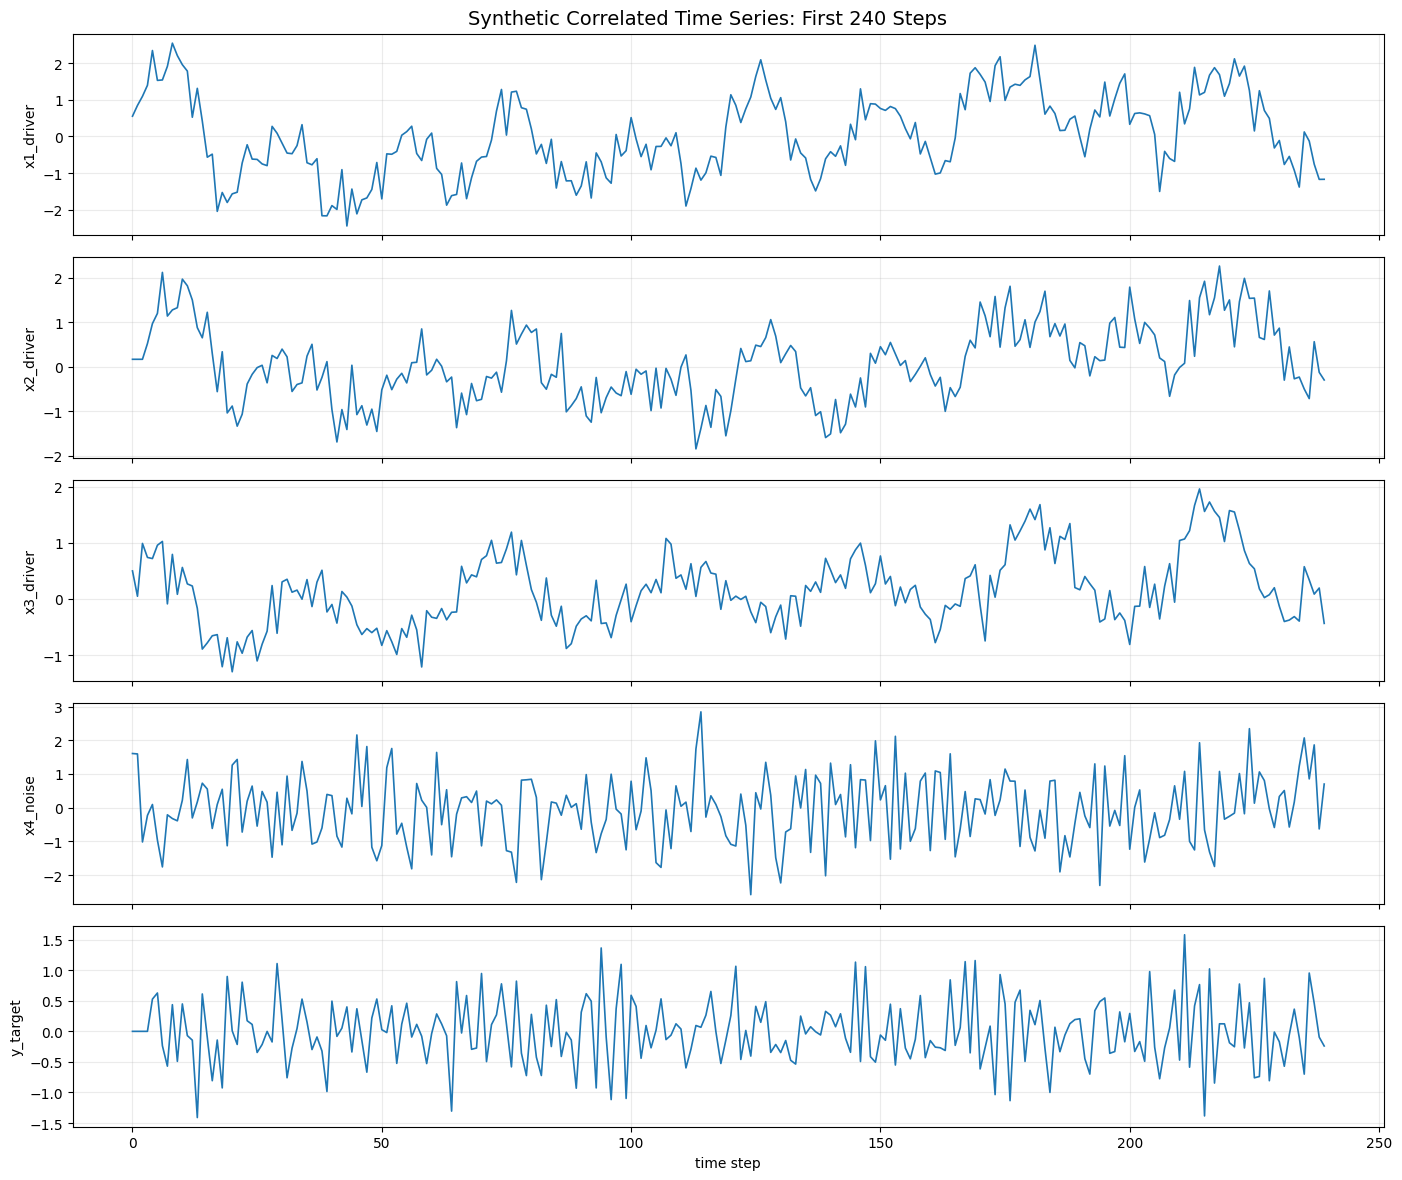

In [27]:
plot_df = df.iloc[:240]

fig, axes = plt.subplots(5, 1, figsize=(14, 12), sharex=True)
for ax, col in zip(axes, ["x1_driver", "x2_driver", "x3_driver", "x4_noise", "y_target"]):
    ax.plot(plot_df["t"], plot_df[col], linewidth=1.2)
    ax.set_ylabel(col)
    ax.grid(alpha=0.25)
axes[-1].set_xlabel("time step")
fig.suptitle("Synthetic Correlated Time Series: First 240 Steps", fontsize=14)
plt.tight_layout()
plt.show()

In [29]:
corr = df.drop(columns=["t"]).corr()
corr.style.background_gradient(cmap="RdBu_r", axis=None).format("{:.2f}")

,x1_driver,x2_driver,x3_driver,x4_noise,y_target
x1_driver,1.00,0.70,0.10,-0.02,0.05
x2_driver,0.70,1.00,0.07,-0.02,-0.19
x3_driver,0.10,0.07,1.00,-0.01,0.02
x4_noise,-0.02,-0.02,-0.01,1.00,-0.01
y_target,0.05,-0.19,0.02,-0.01,1.00


A useful caution:

- simple correlation only measures same-time linear association
- our target was built using lagged driver values
- so some truly useful relationships may look weaker than they really are in the plain correlation table

In [30]:
lag_summary = pd.DataFrame(
    {
        "corr_y_with_x1_lag1": [pd.Series(y_target[1:]).corr(pd.Series(x1_driver[:-1]))],
        "corr_y_with_x2_lag3": [pd.Series(y_target[3:]).corr(pd.Series(x2_driver[:-3]))],
        "corr_y_with_x3_lag2": [pd.Series(y_target[2:]).corr(pd.Series(x3_driver[:-2]))],
    }
)
lag_summary.T.rename(columns={0: "value"})

,value
corr_y_with_x1_lag1,0.137816
corr_y_with_x2_lag3,-0.237185
corr_y_with_x3_lag2,0.010787


## 4. Build Training Windows

We will compare two forecasting setups:

1. **Univariate TCN**
   - input channels: only `y_target`
   - target: next `y_target`

2. **Multivariate TCN**
   - input channels: `x1_driver`, `x2_driver`, `x3_driver`, `x4_noise`, `y_target`
   - target: next `y_target`

This lets us directly test whether the extra related series help forecast the target.

In [31]:
feature_cols_multi = ["x1_driver", "x2_driver", "x3_driver", "x4_noise", "y_target"]
feature_cols_uni = ["y_target"]

train_end = int(0.70 * len(df))
valid_end = int(0.85 * len(df))

train_df = df.iloc[:train_end].copy()
valid_df = df.iloc[train_end:valid_end].copy()
test_df = df.iloc[valid_end:].copy()

feature_means = train_df[feature_cols_multi].mean()
feature_stds = train_df[feature_cols_multi].std().replace(0, 1.0)

scaled_df = df.copy()
scaled_df[feature_cols_multi] = (scaled_df[feature_cols_multi] - feature_means) / feature_stds

target_mean = feature_means[TARGET_COL]
target_std = feature_stds[TARGET_COL]

train_df.shape, valid_df.shape, test_df.shape

((2240, 6), (480, 6), (480, 6))

In [32]:
def build_windows(frame, feature_cols, target_col, lookback=48, horizon=1):
    X_list, y_list, meta_list = [], [], []
    values = frame[feature_cols].to_numpy(dtype=np.float32)
    target_values = frame[target_col].to_numpy(dtype=np.float32)
    t_values = frame["t"].to_numpy()

    for end_idx in range(lookback, len(frame) - horizon + 1):
        start_idx = end_idx - lookback
        target_idx = end_idx + horizon - 1

        X_window = values[start_idx:end_idx].T
        y_target = target_values[target_idx]

        X_list.append(X_window)
        y_list.append(y_target)
        meta_list.append(
            {
                "window_end_t": int(t_values[end_idx - 1]),
                "target_t": int(t_values[target_idx]),
            }
        )

    return (
        np.array(X_list, dtype=np.float32),
        np.array(y_list, dtype=np.float32),
        pd.DataFrame(meta_list),
    )

In [33]:
X_train_uni, y_train, meta_train_uni = build_windows(
    scaled_df.iloc[:train_end], feature_cols_uni, TARGET_COL, lookback=LOOKBACK, horizon=HORIZON
)
X_valid_uni, y_valid, meta_valid_uni = build_windows(
    scaled_df.iloc[train_end:valid_end], feature_cols_uni, TARGET_COL, lookback=LOOKBACK, horizon=HORIZON
)
X_test_uni, y_test, meta_test_uni = build_windows(
    scaled_df.iloc[valid_end:], feature_cols_uni, TARGET_COL, lookback=LOOKBACK, horizon=HORIZON
)

X_train_multi, _, meta_train_multi = build_windows(
    scaled_df.iloc[:train_end], feature_cols_multi, TARGET_COL, lookback=LOOKBACK, horizon=HORIZON
)
X_valid_multi, _, meta_valid_multi = build_windows(
    scaled_df.iloc[train_end:valid_end], feature_cols_multi, TARGET_COL, lookback=LOOKBACK, horizon=HORIZON
)
X_test_multi, _, meta_test_multi = build_windows(
    scaled_df.iloc[valid_end:], feature_cols_multi, TARGET_COL, lookback=LOOKBACK, horizon=HORIZON
)

print("Univariate train shape:", X_train_uni.shape)
print("Multivariate train shape:", X_train_multi.shape)
print("Target shape:", y_train.shape)

Univariate train shape: (2192, 1, 48)
Multivariate train shape: (2192, 5, 48)
Target shape: (2192,)


Interpret the shapes carefully:

- univariate input shape: `(num_windows, 1, LOOKBACK)`
- multivariate input shape: `(num_windows, 5, LOOKBACK)`
- target shape: `(num_windows,)`

So we are still predicting **one target series**. We just give the multivariate model more channels to learn from.

## 5. Dataset And TCN Model

The TCN sees tensors with shape:

`batch x channels x time`

The final linear layer outputs one number: the next `y_target`.

In [9]:
class SequenceDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [10]:
class Chomp1d(nn.Module):
    def __init__(self, chomp_size):
        super().__init__()
        self.chomp_size = chomp_size

    def forward(self, x):
        return x[:, :, :-self.chomp_size] if self.chomp_size > 0 else x


class TemporalBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, dilation, dropout):
        super().__init__()
        padding = (kernel_size - 1) * dilation

        self.net = nn.Sequential(
            nn.Conv1d(in_channels, out_channels, kernel_size, padding=padding, dilation=dilation),
            Chomp1d(padding),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Conv1d(out_channels, out_channels, kernel_size, padding=padding, dilation=dilation),
            Chomp1d(padding),
            nn.ReLU(),
            nn.Dropout(dropout),
        )
        self.downsample = nn.Conv1d(in_channels, out_channels, 1) if in_channels != out_channels else None
        self.relu = nn.ReLU()

    def forward(self, x):
        out = self.net(x)
        res = x if self.downsample is None else self.downsample(x)
        return self.relu(out + res)


class SimpleTCN(nn.Module):
    def __init__(self, in_channels, hidden_channels=HIDDEN_CHANNELS, dropout=DROPOUT):
        super().__init__()
        self.tcn = nn.Sequential(
            TemporalBlock(in_channels, hidden_channels, kernel_size=3, dilation=1, dropout=dropout),
            TemporalBlock(hidden_channels, hidden_channels, kernel_size=3, dilation=2, dropout=dropout),
            TemporalBlock(hidden_channels, hidden_channels, kernel_size=3, dilation=4, dropout=dropout),
        )
        self.head = nn.Linear(hidden_channels, 1)

    def forward(self, x):
        z = self.tcn(x)
        last_step = z[:, :, -1]
        out = self.head(last_step)
        return out.squeeze(-1)

## 6. Training Helper

We use the same training loop for both the univariate and multivariate models.

That makes the comparison fair.

In [34]:
def train_tcn_model(X_train, y_train, X_valid, y_valid, in_channels, epochs=EPOCHS):
    train_loader = DataLoader(SequenceDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True)
    valid_loader = DataLoader(SequenceDataset(X_valid, y_valid), batch_size=BATCH_SIZE, shuffle=False)

    model = SimpleTCN(in_channels=in_channels).to(device)
    loss_fn = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

    history = []

    for epoch in range(epochs):
        model.train()
        train_losses = []

        for xb, yb in train_loader:
            xb = xb.to(device)
            yb = yb.to(device)

            optimizer.zero_grad()
            pred = model(xb)
            loss = loss_fn(pred, yb)
            loss.backward()
            optimizer.step()

            train_losses.append(loss.item())

        model.eval()
        valid_losses = []
        with torch.no_grad():
            for xb, yb in valid_loader:
                xb = xb.to(device)
                yb = yb.to(device)
                pred = model(xb)
                loss = loss_fn(pred, yb)
                valid_losses.append(loss.item())

        history.append(
            {
                "epoch": epoch + 1,
                "train_loss": float(np.mean(train_losses)),
                "valid_loss": float(np.mean(valid_losses)),
            }
        )

    history_df = pd.DataFrame(history)
    return model, history_df

## 7. Train Both Models

We train:
- a univariate TCN on just the target history
- a multivariate TCN on the target plus the related driver series

In [35]:
model_uni, history_uni = train_tcn_model(
    X_train_uni, y_train, X_valid_uni, y_valid, in_channels=X_train_uni.shape[1]
)

model_multi, history_multi = train_tcn_model(
    X_train_multi, y_train, X_valid_multi, y_valid, in_channels=X_train_multi.shape[1]
)

history_uni.head(), history_multi.head()

(   epoch  train_loss  valid_loss
 0      1    1.197161    0.918377
 1      2    0.907549    0.853979
 2      3    0.848256    0.840857
 3      4    0.838865    0.833076
 4      5    0.834764    0.834465,
    epoch  train_loss  valid_loss
 0      1    0.774665    0.710272
 1      2    0.627761    0.560515
 2      3    0.495861    0.404397
 3      4    0.421349    0.342327
 4      5    0.372163    0.308358)

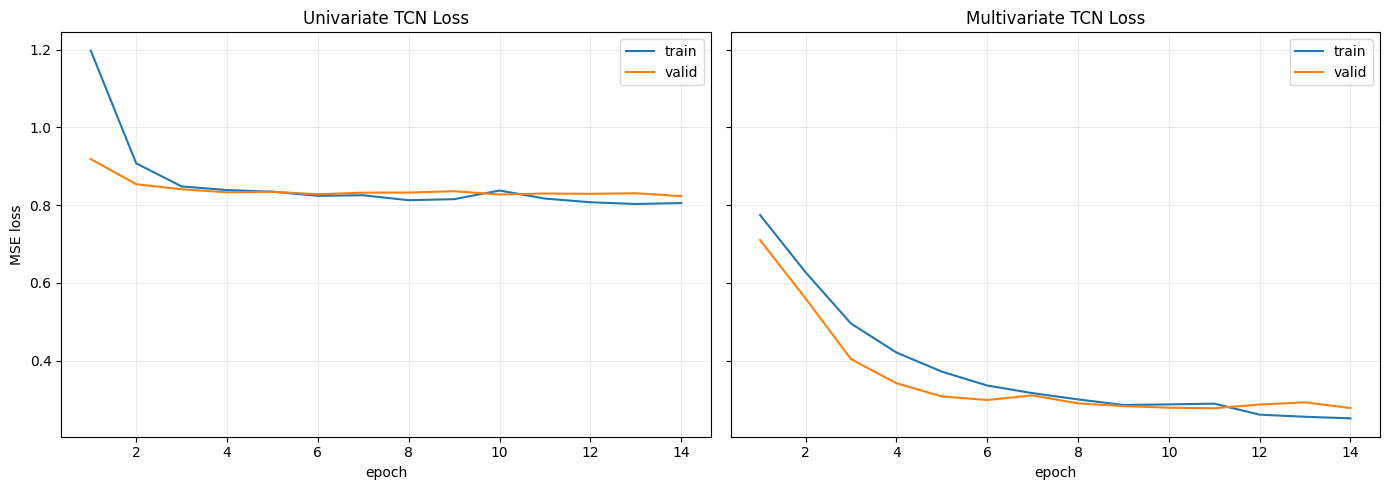

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

axes[0].plot(history_uni["epoch"], history_uni["train_loss"], label="train")
axes[0].plot(history_uni["epoch"], history_uni["valid_loss"], label="valid")
axes[0].set_title("Univariate TCN Loss")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("MSE loss")
axes[0].legend()
axes[0].grid(alpha=0.25)

axes[1].plot(history_multi["epoch"], history_multi["train_loss"], label="train")
axes[1].plot(history_multi["epoch"], history_multi["valid_loss"], label="valid")
axes[1].set_title("Multivariate TCN Loss")
axes[1].set_xlabel("epoch")
axes[1].legend()
axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.show()

## 8. Evaluate On The Test Split

The model predicts scaled `y_target`, so we convert predictions back to the original target scale before computing metrics.

In [37]:
def predict_model(model, X):
    model.eval()
    preds = []
    with torch.no_grad():
        for start in range(0, len(X), BATCH_SIZE):
            xb = torch.tensor(X[start:start + BATCH_SIZE], dtype=torch.float32, device=device)
            pred = model(xb).cpu().numpy()
            preds.append(pred)
    return np.concatenate(preds)


def unscale_target(values_scaled, mean, std):
    return values_scaled * std + mean

In [38]:
pred_test_uni_scaled = predict_model(model_uni, X_test_uni)
pred_test_multi_scaled = predict_model(model_multi, X_test_multi)

y_test_raw = unscale_target(y_test, target_mean, target_std)
pred_test_uni_raw = unscale_target(pred_test_uni_scaled, target_mean, target_std)
pred_test_multi_raw = unscale_target(pred_test_multi_scaled, target_mean, target_std)

metrics_df = pd.DataFrame(
    {
        "model": ["univariate_tcn", "multivariate_tcn"],
        "mae": [
            mean_absolute_error(y_test_raw, pred_test_uni_raw),
            mean_absolute_error(y_test_raw, pred_test_multi_raw),
        ],
        "rmse": [
            float(np.sqrt(mean_squared_error(y_test_raw, pred_test_uni_raw))),
            float(np.sqrt(mean_squared_error(y_test_raw, pred_test_multi_raw))),
        ],
        "r2": [
            r2_score(y_test_raw, pred_test_uni_raw),
            r2_score(y_test_raw, pred_test_multi_raw),
        ],
    }
)

metrics_df

,model,mae,rmse,r2
0,univariate_tcn,0.358002,0.443308,0.148369
1,multivariate_tcn,0.213867,0.267376,0.690197


If the multivariate model is working as intended, it should usually:
- reduce `MAE`
- reduce `RMSE`
- improve `R^2`

That would mean the model is learning useful information from the extra channels.

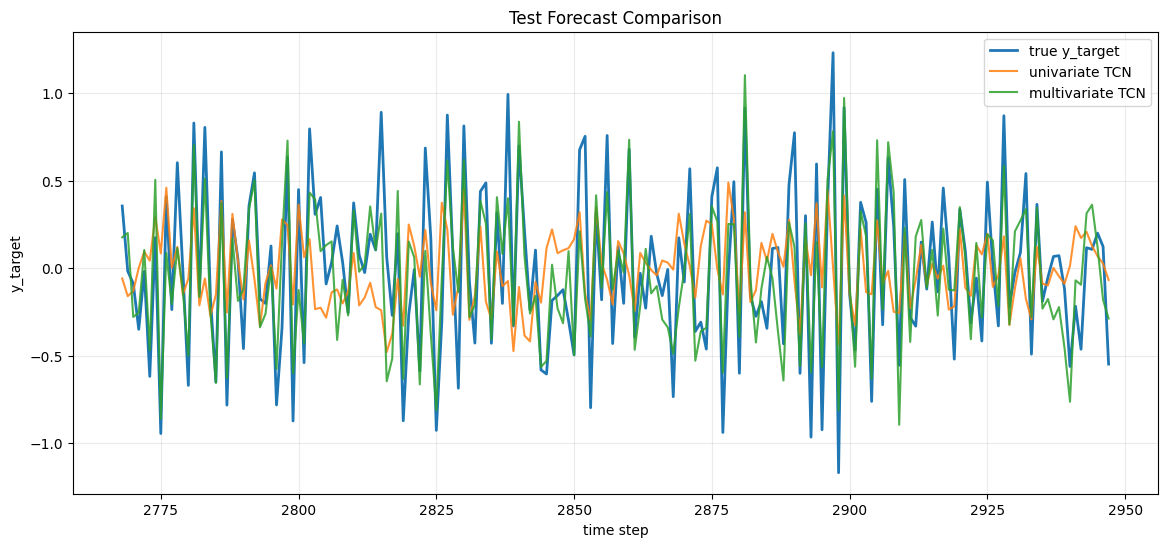

In [39]:
plot_n = 180
plot_t = meta_test_uni["target_t"].iloc[:plot_n]

plt.figure(figsize=(14, 6))
plt.plot(plot_t, y_test_raw[:plot_n], label="true y_target", linewidth=2)
plt.plot(plot_t, pred_test_uni_raw[:plot_n], label="univariate TCN", alpha=0.85)
plt.plot(plot_t, pred_test_multi_raw[:plot_n], label="multivariate TCN", alpha=0.85)
plt.title("Test Forecast Comparison")
plt.xlabel("time step")
plt.ylabel("y_target")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

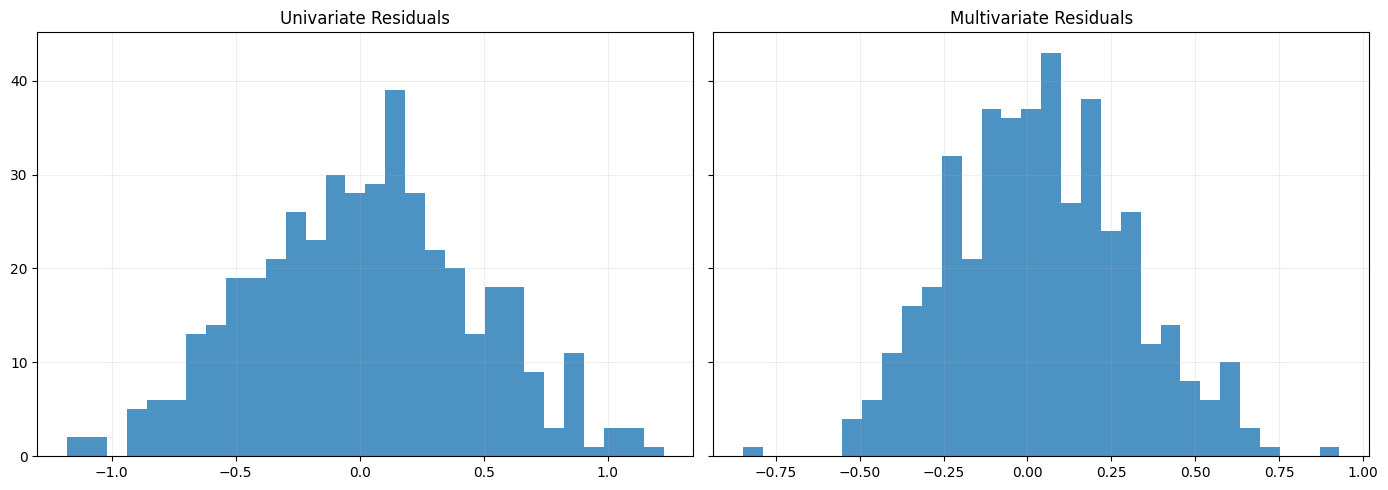

In [42]:
resid_df = pd.DataFrame(
    {
        "t": meta_test_uni["target_t"],
        "resid_uni": y_test_raw - pred_test_uni_raw,
        "resid_multi": y_test_raw - pred_test_multi_raw,
    }
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
axes[0].hist(resid_df["resid_uni"], bins=30, alpha=0.8)
axes[0].set_title("Univariate Residuals")
axes[0].grid(alpha=0.20)

axes[1].hist(resid_df["resid_multi"], bins=30, alpha=0.8)
axes[1].set_title("Multivariate Residuals")
axes[1].grid(alpha=0.20)

plt.tight_layout()
plt.show()

## 9. What To Try Next

Now that this setup is working, good next experiments are:

- remove `x4_noise` and see whether the model improves
- predict 3 steps ahead instead of 1 by setting `HORIZON = 3`
- make the target depend on longer lags and increase `LOOKBACK`
- predict more than one target at once by changing the model head
- compare TCN against a simple dense network or linear baseline

## 10. Takeaway

This notebook is meant to make one idea concrete:

- if the target series is influenced by other series,
- and those series are aligned in time,
- then a multivariate TCN can often learn those cross-series relationships better than a univariate model

The key conceptual shift is:

- **univariate TCN**: one channel in, one target out
- **multivariate TCN**: many channels in, one target out

Later, we can extend this again to:

- many channels in, many targets out